!export CUDA_VISIBLE_DEVICES="0,1"


In [1]:
from typing import Dict, List, Union, Tuple, Callable
import itertools
import random
import numpy as np
import deepxde as dde
from deepxde.backend import tf
import time
import os
#os.environ["CUDA_VISIBLE_DEVICES"]="0,1"

/home/hpcs_rnd/anaconda3/envs/Ravindra_env/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
Using backend: tensorflow.compat.v1
Other supported backends: tensorflow, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Instructions for updating:
non-resource variables are not supported in the long term


Enable just-in-time compilation with XLA.



constans

In [6]:
# Define some constants
DIRICHLET = "Dirichlet"
NEUMANN = "Neumann"
ROBIN = "Robin"
INTERVAL = "Interval"
RECTANGLE = "Rectangle"
HEAT_EQUATION_1D = "1d"
HEAT_EQUATION_2D = "2d"
DEGREE = "degree"
BASIS_FUNCTIONS = "phi"
NUM_TIME_STEPS = "num_time_steps"
ODE_SOLVER = "theta"
DX = "dx"
DS = "ds"
TIME_DEPENDENT = "time_dependent"
TIME_INDEPENDENT = "time_independent"
CONSTANT = "constant"
NUM_DOMAIN = "num_domain"
NUM_INITIAL = "num_initial"
NUM_BOUNDARY = "num_boundary"
NUM_NEURONS = "num_neurons"
NUM_HIDDEN_LAYER = "num_hidden_layer"
ACTIVATION = "activation"
INITIALIZER = "initializer"
OPTIMIZER = "optimizer"
LEARNING_RATE = "learning_rate"
LOSS_WEIGHTS = "loss_weights"
EPOCHS = "epochs"
ALL = "all"
TOP_BOTTOM = "TopBottom"
LEFT_RIGHT = "LeftRight"
NX = "nx"
NY = "ny"
EXACT = "exact"
FEM = "fem"
PINN = "pinn"

# Dict mapping the different test problems to the different domain types
TEST_PROBLEM_TO_DOMAIN_DICT = {
    HEAT_EQUATION_1D: INTERVAL,
    HEAT_EQUATION_2D: RECTANGLE,
}

In [7]:

def build_hyper_parameter_space(
    maximal_trials: int,
    hyper_parameter_lists: List[List[float]]
) -> List[Tuple[float]]:
    """
    Creates hyper parameter product space for tuning model architecture, training process, etc.

    :param maximal_trials:              Total number of trials to run during the search.
    :param hyper_parameter_lists:       List of lists containing the different parameters to search from
    :return:                            List of tuples containing the different parameters for the model
    """
    hyper_parameter_product_space = list(itertools.product(*hyper_parameter_lists))
    print(f"Dimension of hyper_parameter_product_space = {len(hyper_parameter_product_space)}")

    # Shuffle the product space and picking a few trials because searching the whole space is not feasible
    random.seed(0)
    random.shuffle(hyper_parameter_product_space)

    return hyper_parameter_product_space[:min(maximal_trials, len(hyper_parameter_product_space))]

PINN --> boundary

In [8]:

class Boundary:
    """
    Class for holding python functions that specifies which points belong to which part of the boundary for PINN.
    """

    def __init__(self, domain_type: str, boundary_type: str) -> None:
        """
        Constructor of this class.
        Will be called when an object is created from this class and
        allows the class to initialize the attributes of the class.

        :param domain_type:         Name of the domain type (e.g. interval or rectangle).
        :param boundary_type:       Name of the part of the boundary.
        """
        self.boundary = self.BOUNDARY_TYPE_DICT[domain_type][boundary_type]

    @staticmethod
    def boundary_all(x, on_boundary):
        return on_boundary

    @staticmethod
    def rectangle_left_right(x, on_boundary):
        return on_boundary and (np.isclose(x[0], 0) or np.isclose(x[0], 1))

    @staticmethod
    def rectangle_top_bottom(x, on_boundary):
        return on_boundary and (np.isclose(x[1], 0) or np.isclose(x[1], 1))


    # Dicts holding functions for different domain types and parts of the boundary
    BOUNDARY_INTERVAL_DICT = {
        ALL: boundary_all.__func__,
    }

    BOUNDARY_RECTANGLE_DICT = {
        ALL: boundary_all.__func__,
        TOP_BOTTOM: rectangle_top_bottom.__func__,
        LEFT_RIGHT: rectangle_left_right.__func__,
    }

    BOUNDARY_TYPE_DICT = {
        INTERVAL: BOUNDARY_INTERVAL_DICT,
        RECTANGLE: BOUNDARY_RECTANGLE_DICT,
    }

PINN --> domain

In [9]:
def set_domain_interval() -> dde.geometry:
    """
    Defines the interval with endpoints 0 and 1 as the computational geometry.

    :return:    The computational geometry.
    """
    return dde.geometry.Interval(0, 1)


def set_domain_rectangle() -> dde.geometry:
    """
    Defines the rectangle with bottom left corner [0, 0] and top right corner [1, 1] as the computational geometry.

    :return:    The computational geometry.
    """
    return dde.geometry.Rectangle([0, 0], [1, 1])


# Dict holding geometry functions for different domain types
DOMAIN_TYPE_DICT = {
    INTERVAL: set_domain_interval,
    RECTANGLE: set_domain_rectangle,
}

PINN --> expression

In [10]:

def test_problem_1d():
    """
    Contains the inhomogeneity of the heat equation, the initial condition,
    the inhomogeneities of the boundary conditions and the solution
    of the 1D test problem, see Section 5.1.

    :return:    Data of the test problem as python functions or
                dict with key part of boundary and python functions as values.
    """
    # x = x[:, 0:1], t = x[:, 1:2]

    def f(x): return 0

    def initial(x): return tf.sin(2 * np.pi * x[:, 0:1])

    def dirichlet(x): return 0

    def solution(x): return np.exp(-4 * np.pi * np.pi * x[:, 1:2]) * np.sin(2 * np.pi * x[:, 0:1])

    return (
        f,
        initial,
        {ALL: dirichlet},
        {},
        {},
        solution
    )


def test_problem_2d():
    """
    Contains the inhomogeneity of the heat equation, the initial condition,
    the inhomogeneities of the boundary conditions and the solution
    of the 2D test problem, see Section 5.2.

    :return:    Data of the test problem as python functions or
                dict with key part of boundary and python functions as values.
    """
    # x = x[:, 0:1], y = x[:, 1:2], t = x[:, 2:3]

    pi_squared = np.pi * np.pi

    def f(x): return 4 * pi_squared * tf.exp(-4 * pi_squared * x[:, 2:3]) * \
                     tf.cos(2 * np.pi * x[:, 0:1]) * tf.cos(2 * np.pi * x[:, 1:2])

    def initial(x): return tf.cos(2 * np.pi * x[:, 0:1]) * tf.cos(2 * np.pi * x[:, 1:2])

    def dirichlet(x): return tf.exp(-4 * pi_squared * x[:, 2:3])  * tf.cos(2 * np.pi * x[:, 1:2])

    def neumann(x): return 0

    def solution(x): return tf.exp(-4 * pi_squared * x[:, 2:3]) * \
                            tf.cos(2 * np.pi * x[:, 0:1]) * tf.cos(2 * np.pi * x[:, 1:2])

    return (
        f,
        initial,
        {LEFT_RIGHT: dirichlet},
        {TOP_BOTTOM: neumann},
        {},
        solution
    )


# Dicts holding the data of the different test problems for different domain types
EXPRESSION_INTERVAL_DICT = {
    HEAT_EQUATION_1D: test_problem_1d
}

EXPRESSIONS_RECTANGLE_DICT = {
    HEAT_EQUATION_2D: test_problem_2d
}

EXPRESSIONS_TYPE_DICT = {
    INTERVAL: EXPRESSION_INTERVAL_DICT,
    RECTANGLE: EXPRESSIONS_RECTANGLE_DICT,
}


In [11]:

class PINNSolver:
    """
    Class for solving the heat equation with physics-informed neural networks (PINN).
    """

    def __init__(self, test_problem_str: str, T: float) -> None:
        """
        Constructor of this class.
        Will be called when an object is created from this class and
        allows the class to initialize the attributes of the class.

        :param test_problem_str:    Name of the test problem.
        :param T:                   Final time.
        """
        self.test_problem_str = test_problem_str
        self.T = T
        self.domain_type = TEST_PROBLEM_TO_DOMAIN_DICT[self.test_problem_str]

        self.f = None
        self.initial = None
        self.dirichlet = None
        self.neumann = None
        self.robin = None
        self.solution = None

        self.boundaries_assignment_dict = None
        self.num_dirichlet_sectors = None
        self.num_neumann_sectors = None
        self.num_robin_sectors = None

        self.domain = None
        self.on_boundary = None
        self.initial_boundary_conditions = None

    def setup_test_problem(self) -> None:
        """
        Initializing the inhomogeneity of the heat equation, the initial condition,
        the inhomogeneities of the boundary conditions and the solution.

        :return:    None
        """
        self.f, self.initial, self.dirichlet, self.neumann, self.robin, self.solution = \
            EXPRESSIONS_TYPE_DICT[self.domain_type][self.test_problem_str]()

        # Assign the different parts of the boundary to the different boundary types
        self.boundaries_assignment_dict = {
            DIRICHLET: list(self.dirichlet.keys()),
            NEUMANN: list(self.neumann.keys()),
            ROBIN: list(self.robin.keys())
        }
        self.num_dirichlet_sectors = 0 if self.dirichlet is None else len(self.boundaries_assignment_dict[DIRICHLET])
        self.num_neumann_sectors = 0 if self.neumann is None else len(self.boundaries_assignment_dict[NEUMANN])
        self.num_robin_sectors = 0 if self.robin is None else len(self.boundaries_assignment_dict[ROBIN])

    def set_boundary_types(self) -> None:
        """
        Defines python functions for the different parts of the boundary.
        The functions should return booleans depending whether a point is on the boundary or not.

        :return:    None
        """
        self.on_boundary = {
            key: Boundary(self.domain_type, key).boundary
            for key in (
                self.boundaries_assignment_dict[DIRICHLET] +
                self.boundaries_assignment_dict[NEUMANN] +
                self.boundaries_assignment_dict[ROBIN]
            )
        }

    def set_domain(self) -> None:
        """
        Defines the computational geometry.

        :return:    None
        """
        space_domain = DOMAIN_TYPE_DICT[self.domain_type]()
        time_domain = dde.geometry.TimeDomain(0, self.T)

        # Combine both space and time domain
        self.domain = dde.geometry.GeometryXTime(space_domain, time_domain)

    def set_boundary_conditions(self) -> None:
        """
        Assign the initial condition and the different boundary conditions to the different parts of the boundary.

        :return:    None
        """
        # Initial condition
        self.initial_boundary_conditions = [
            dde.IC(self.domain, self.initial, lambda _, on_initial: on_initial)
        ]

        # Boundary conditions
        if self.num_dirichlet_sectors > 0:
            for key in self.boundaries_assignment_dict[DIRICHLET]:
                self.initial_boundary_conditions.append(
                    dde.DirichletBC(self.domain, self.dirichlet[key], self.on_boundary[key])
                )
        if self.num_neumann_sectors > 0:
            for key in self.boundaries_assignment_dict[NEUMANN]:
                self.initial_boundary_conditions.append(
                    dde.NeumannBC(self.domain, self.neumann[key], self.on_boundary[key])
                )
        if self.num_robin_sectors > 0:
            for key in self.boundaries_assignment_dict[ROBIN]:
                self.initial_boundary_conditions.append(
                    dde.RobinBC(self.domain, self.robin[key], self.on_boundary[key])
                )

    def init_time_dependent_pde_solver(self, pde_solver_args: Dict[str, int]) -> dde.data.TimePDE:
        """
        Defines the time-dependent PDE problem.

        :param pde_solver_args:     Dict with keys NUM_DOMAIN, NUM_BOUNDARY and NUM_INITIAL with
                                    number of training points sampled inside the domain,
                                    on the initial location and on the boundary as values.
        :return:                    Time-dependent PDE solver.
        """
        return dde.data.TimePDE(
            geometryxtime=self.domain,
            pde=self.heat_equation,
            ic_bcs=self.initial_boundary_conditions,
            num_domain=pde_solver_args[NUM_DOMAIN],
            num_boundary=pde_solver_args[NUM_BOUNDARY],
            num_initial=pde_solver_args[NUM_INITIAL],
            train_distribution="pseudo",
            solution=self.solution,
            num_test=None
        )

    def init_neural_network(
        self,
        neural_network_args: Dict[str, int],
        hard_constraint: Callable = None
    ) -> dde.maps.FNN:
        """
        Configures the neural network.

        :param neural_network_args:     Dict with keys NUM_NEURONS, NUM_HIDDEN_LAYER, ACTIVATION and INITIALIZER with
                                        number of neurons per layer, number of hidden layers,
                                        the activation function and kernel initializer as values.
        :param hard_constraint:         Function that transforms the network output
                                        for exact initial and boundary conditions if not None.
        :return:                        Fully-connected neural network.
        """
        net = dde.maps.FNN(
            [self.domain.dim] + \
            [neural_network_args[NUM_NEURONS]] * neural_network_args[NUM_HIDDEN_LAYER] + \
            [1],
            neural_network_args[ACTIVATION],
            neural_network_args[INITIALIZER]
        )
        if hard_constraint is not None:
            net.apply_output_transform(hard_constraint)
        return net

    @staticmethod
    def train_model(
        time_pde_solver: dde.data.TimePDE,
        neural_network: dde.maps.FNN,
        optimizer_args: Dict[str, Union[str, int, List[float]]]
    ) -> Tuple[dde.Model, dde.model.LossHistory, dde.model.TrainState]:
        """
        Builds and trains the model.

        :param time_pde_solver:     Time-dependent PDE solver.
        :param neural_network:      Fully-connected neural network.
        :param optimizer_args:      Dict with keys OPTIMIZER, LEARNING_RATE, LOSS_WEIGHTS and EPOCHS with
                                    name of the optimizer, the learning rate, list of floats to weight
                                    the loss contributions and number of iterations to train the model as values.
        :return:                    Model, loss history and train state objects.
        """
        model = dde.Model(time_pde_solver, neural_network)

        # Resample the training points for PDE losses every given period.
        resampler = dde.callbacks.PDEPointResampler(period=100)

        # Configure the model for training
        model.compile(
            optimizer_args[OPTIMIZER],
            optimizer_args[LEARNING_RATE],
            loss_weights=optimizer_args[LOSS_WEIGHTS]
        )

        # Trains the model
        loss_history, train_state = model.train(epochs=optimizer_args[EPOCHS], callbacks=[resampler])  #, callbacks=[resampler]

        return model, loss_history, train_state

    def heat_equation(self, x, u):
        """
        Defines the PDE residual of the N-dimensional heat equation.

        :param x:   Space-time coordinates as (N + 1)-vectors.
        :param u:   Temperature in point x.
        :return:    PDE residual.
        """
        u_t = dde.grad.jacobian(u, x, i=0, j=1)
        u_xx = dde.grad.hessian(u, x, i=0, j=0)
        return u_t - u_xx - self.f(x)

hyper parameter tunning

In [12]:
# Set default float type for PINN solver
DTYPE = "float64"
dde.config.set_default_float(DTYPE)

# Final time
T = 0.1

# Use hard_constraint = True for exact initial and boundary conditions for PINN solver
hard_constraint = False

Set the default float type to float64


In [13]:
# Use hard_constraint = True for exact initial and boundary conditions for PINN solver
hard_constraint = False

# Define run id
run_id = "run_1d_test"

# Number of iterations to train the model
epochs = 75000

# Define hyper parameter to search from during tuning
hyper_parameter_lists=[
    [12],       # 0: NUM_NEURONS
    [4],        # 1: NUM_HIDDEN_LAYER
    [1e-3],     # 2: LEARNING_RATE
    [1000],     # 3: NUM_DOMAIN
    [1000],     # 4: NUM_INITIAL
    [1000],     # 5: NUM_BOUNDARY
]

# Use NUM_INITIAL = NUM_BOUNDARY = 1 for exact initial and boundary conditions
# Setting 0 instead of 1 results in weird behaviour
if hard_constraint:
    hyper_parameter_lists[4] = hyper_parameter_lists[5] = [1]

# Create hyper parameter product space for tuning
hyper_parameter_product_space = build_hyper_parameter_space(
    maximal_trials=25,
    hyper_parameter_lists=hyper_parameter_lists
)

Dimension of hyper_parameter_product_space = 1


test_1d

In [ ]:
# Initialize timer array
timer_pinn = []

# Iterate over the hyper parameter product space
for hyper_parameter in hyper_parameter_product_space:

    # # Define name of folder for saving the figures to for this trial
    # name = f"{run_id}_hc{hard_constraint}_nn{hyper_parameter[0]}_nhl{hyper_parameter[1]}_lr{hyper_parameter[2]}_" \
    #        f"ndom{hyper_parameter[3]}_nic{hyper_parameter[4]}_nbc{hyper_parameter[5]}_epochs{epochs}"

    # folder_path = f"assets/{name}"
    # while os.path.isdir(folder_path):
    #     folder_path += "_new"
    # os.mkdir(folder_path)

    # print(f"Start trial {hyper_parameter_product_space.index(hyper_parameter) + 1} with hyper_parameter {name}\n")

    # Start timer
    start_pinn = time.time()

    # Initialize PINN solver class instance
    solver_pinn = PINNSolver(
        test_problem_str=HEAT_EQUATION_1D,
        T=T
    )
    solver_pinn.setup_test_problem()
    solver_pinn.set_boundary_types()
    solver_pinn.set_domain()
    solver_pinn.set_boundary_conditions()

    # Define the PDE problem and configure the network
    pde_solver = solver_pinn.init_time_dependent_pde_solver(
        {NUM_DOMAIN: hyper_parameter[3], NUM_INITIAL: hyper_parameter[4], NUM_BOUNDARY: hyper_parameter[5]}
    )
    
    hard_constraint_fn = (
        lambda x, u: u * x[:, 1:2] * x[:, 0:1] * (1 - x[:, 0:1]) + solver_pinn.initial(x)
    ) if hard_constraint else None
    neural_net = solver_pinn.init_neural_network(
        {
            NUM_NEURONS: hyper_parameter[0], NUM_HIDDEN_LAYER: hyper_parameter[1],
            ACTIVATION: "tanh", INITIALIZER: "Glorot uniform"
        },
        # x = x[:, 0:1], t = x[:, 1:2]
        hard_constraint_fn
    )

    # Build and train the model
    model, loss, train = solver_pinn.train_model(
        pde_solver,
        neural_net,
        {
            OPTIMIZER: "L-BFGS",
            LEARNING_RATE: hyper_parameter[2],
            EPOCHS: epochs,
            LOSS_WEIGHTS: [1, 0, 0] if hard_constraint else [1, 1, 1]
        }
    )

    # Determine computational time
    end_pinn = time.time()
    timer_pinn.append(end_pinn - start_pinn)


Compiling model...
Building feed-forward neural network...
'build' took 0.050136 s



/home/hpcs_rnd/anaconda3/envs/Ravindra_env/lib/python3.9/site-packages/deepxde/nn/tensorflow_compat_v1/fnn.py:116: UserWarning: `tf.layers.dense` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Dense` instead.
  return tf.layers.dense(
/home/hpcs_rnd/anaconda3/envs/Ravindra_env/lib/python3.9/site-packages/keras/legacy_tf_layers/core.py:261: UserWarning: `layer.apply` is deprecated and will be removed in a future version. Please use `layer.__call__` method instead.
  return layer.apply(inputs)
2024-07-04 13:57:09.235542: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-04 13:57:13.816577: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:39] Overriding allow_growth setting bec

'compile' took 4.873498 s

Training model...



2024-07-04 13:57:14.161932: I tensorflow/compiler/xla/service/service.cc:171] XLA service 0x7fc9480074c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-07-04 13:57:14.161999: I tensorflow/compiler/xla/service/service.cc:179]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2024-07-04 13:57:14.162007: I tensorflow/compiler/xla/service/service.cc:179]   StreamExecutor device (1): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2024-07-04 13:57:14.162013: I tensorflow/compiler/xla/service/service.cc:179]   StreamExecutor device (2): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2024-07-04 13:57:14.162018: I tensorflow/compiler/xla/service/service.cc:179]   StreamExecutor device (3): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2024-07-04 13:57:14.162023: I tensorflow/compiler/xla/service/service.cc:179]   StreamExecutor device (4): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2024-07-04 13:57:14.162029: I tensorflow/c

Step      Train loss                        Test loss                         Test metric
0         [6.44e-02, 4.79e-01, 4.35e-03]    [6.44e-02, 4.79e-01, 4.35e-03]    []  
1000      [3.44e-02, 1.88e-02, 5.70e-03]    [3.44e-02, 1.88e-02, 5.70e-03]        
2000      [1.65e-02, 5.64e-03, 1.24e-03]    [1.65e-02, 5.64e-03, 1.24e-03]        
3000      [6.81e-03, 7.86e-04, 3.76e-04]    [6.81e-03, 7.86e-04, 3.76e-04]        
4000      [3.16e-03, 5.42e-04, 1.78e-04]    [3.16e-03, 5.42e-04, 1.78e-04]        
5000      [2.40e-03, 5.21e-04, 2.30e-04]    [2.40e-03, 5.21e-04, 2.30e-04]        
6000      [1.93e-03, 1.58e-04, 7.48e-05]    [1.93e-03, 1.58e-04, 7.48e-05]        
7000      [1.55e-03, 7.25e-05, 5.13e-05]    [1.55e-03, 7.25e-05, 5.13e-05]        
8000      [9.85e-04, 4.46e-05, 4.51e-05]    [9.85e-04, 4.46e-05, 4.51e-05]        


In [ ]:


# Initialize timer array
timer_pinn = []

# Iterate over the hyper parameter product space
for hyper_parameter in hyper_parameter_product_space:

    # Start timer
    start_pinn = time.time()

    # Initialize PINN solver class instance
    solver_pinn = PINNSolver(
        test_problem_str=HEAT_EQUATION_1D,
        T=T
    )
    solver_pinn.setup_test_problem()
    solver_pinn.set_boundary_types()
    solver_pinn.set_domain()
    solver_pinn.set_boundary_conditions()

    # Define the PDE problem and configure the network
    pde_solver = solver_pinn.init_time_dependent_pde_solver(
        {NUM_DOMAIN: hyper_parameter[3], NUM_INITIAL: hyper_parameter[4], NUM_BOUNDARY: hyper_parameter[5]}
    )

    hard_constraint_fn = (
        lambda x, u: u * x[:, 1:2] * x[:, 0:1] * (1 - x[:, 0:1]) + solver_pinn.initial(x)
    ) if hard_constraint else None
    neural_net = solver_pinn.init_neural_network(
        {
            NUM_NEURONS: hyper_parameter[0], NUM_HIDDEN_LAYER: hyper_parameter[1],
            ACTIVATION: "tanh", INITIALIZER: "Glorot uniform"
        },
        hard_constraint_fn
    )

    # Initial training with Adam
    model, loss, train = solver_pinn.train_model(
        pde_solver,
        neural_net,
        {
            OPTIMIZER: "adam",
            LEARNING_RATE: hyper_parameter[2],
            EPOCHS: min(epochs, 10000),  # Limit to 10,000 epochs or less
            LOSS_WEIGHTS: [1, 0, 0] if hard_constraint else [1, 1, 1]
        }
    )

    # Further training with L-BFGS after 10,000 epochs
    if epochs > 10000:
        model.optimizer = "L-BFGS"  # Switch optimizer to L-BFGS
        model, loss, train = solver_pinn.train_model(
            pde_solver,
            neural_net,
            {
                OPTIMIZER: "L-BFGS",
                LEARNING_RATE: hyper_parameter[2],  # You might not need to set this again
                EPOCHS: epochs - 10000,  # Remaining epochs after Adam
                LOSS_WEIGHTS: [1, 0, 0] if hard_constraint else [1, 1, 1]
            }
        )

    # Determine computational time
    end_pinn = time.time()
    timer_pinn.append(end_pinn - start_pinn)


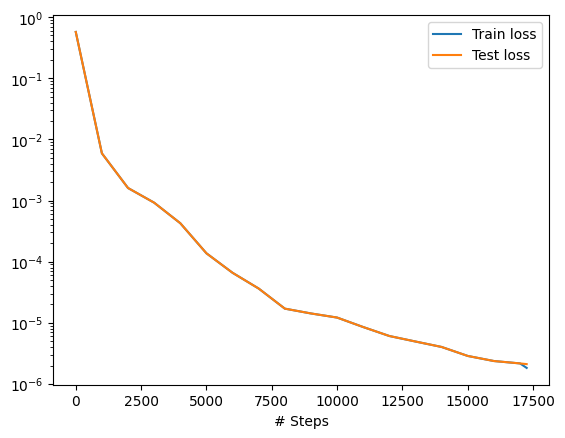

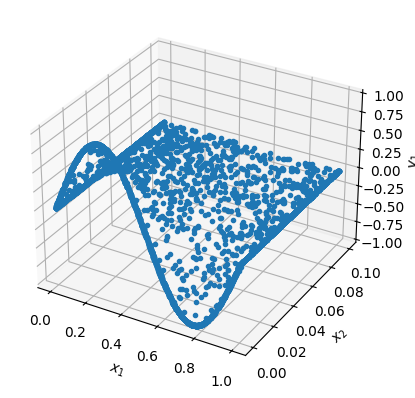

In [52]:
dde.saveplot(loss, train, issave=False, isplot=True) 

In [41]:
data = np.load("/home/hpcs_rnd/RAVINDRA_IISc/heat_equation/solution_fem1.npz")
solution_fem = data['solution_fem1']
time_values_data = data['time_value_data1']

In [42]:
s = np.load('/home/hpcs_rnd/RAVINDRA_IISc/my_data.npz')
function_space = s['arr_0']

In [53]:
exact_solution = np.zeros_like(solution_fem)
solution_pinn = np.zeros_like(solution_fem)

for time_step in range(solution_fem.shape[0]):
        coordinates_data = np.concatenate(
            [
                function_space,
                (time_values_data[time_step] * np.ones(51)).reshape(-1, 1)
            ],
            axis=1
        )

        exact_solution[time_step, :] = np.array(solver_pinn.solution(coordinates_data)).reshape(-1,)
        solution_pinn[time_step, :] = model.predict(coordinates_data).reshape(-1,)

In [54]:
exact_solution[0]

array([-2.44929360e-16, -2.48689887e-01, -1.25333234e-01, -4.81753674e-01,
       -3.68124553e-01, -6.84547106e-01, -5.87785252e-01, -8.44327926e-01,
       -7.70513243e-01, -9.51056516e-01, -9.04827052e-01, -9.98026728e-01,
       -9.82287251e-01, -9.82287251e-01, -9.98026728e-01, -9.04827052e-01,
       -9.51056516e-01, -7.70513243e-01, -8.44327926e-01, -5.87785252e-01,
       -6.84547106e-01, -3.68124553e-01, -4.81753674e-01, -1.25333234e-01,
       -2.48689887e-01,  1.25333234e-01,  1.22464680e-16,  3.68124553e-01,
        2.48689887e-01,  5.87785252e-01,  4.81753674e-01,  7.70513243e-01,
        6.84547106e-01,  9.04827052e-01,  8.44327926e-01,  9.82287251e-01,
        9.51056516e-01,  9.98026728e-01,  9.98026728e-01,  9.51056516e-01,
        9.82287251e-01,  8.44327926e-01,  9.04827052e-01,  6.84547106e-01,
        7.70513243e-01,  4.81753674e-01,  5.87785252e-01,  2.48689887e-01,
        3.68124553e-01,  0.00000000e+00,  1.25333234e-01])

In [55]:
solution_pinn[0]

array([ 4.79957428e-04, -2.48564553e-01, -1.25035251e-01, -4.81905221e-01,
       -3.68151861e-01, -6.84842344e-01, -5.88027016e-01, -8.44623045e-01,
       -7.70825337e-01, -9.51238441e-01, -9.05076478e-01, -9.98040579e-01,
       -9.82387880e-01, -9.82141197e-01, -9.97956131e-01, -9.04575577e-01,
       -9.50849068e-01, -7.70230718e-01, -8.44051387e-01, -5.87542743e-01,
       -6.84276588e-01, -3.67974878e-01, -4.81552506e-01, -1.25302555e-01,
       -2.48598303e-01,  1.25248867e-01, -2.91997735e-05,  3.67956606e-01,
        2.48558369e-01,  5.87583585e-01,  4.81561978e-01,  7.70332815e-01,
        6.84349438e-01,  9.04713376e-01,  8.44176332e-01,  9.82263245e-01,
        9.50986598e-01,  9.98086867e-01,  9.98047106e-01,  9.51176078e-01,
        9.82380590e-01,  8.44484242e-01,  9.04966927e-01,  6.84732549e-01,
        7.70684289e-01,  4.81965274e-01,  5.87984753e-01,  2.48904267e-01,
        3.68342954e-01,  1.37766392e-04,  1.25524337e-01])

In [56]:
solution_pinn[10]- exact_solution[10]

array([ 2.12396133e-04,  1.99958570e-04,  2.11044008e-04,  1.63191912e-04,
        1.83115939e-04,  1.20236480e-04,  1.41857012e-04,  8.00529606e-05,
        9.92974337e-05,  5.08522815e-05,  6.35727201e-05,  3.91560405e-05,
        4.26197482e-05,  4.48645152e-05,  4.01852785e-05,  5.96011883e-05,
        5.18756253e-05,  7.06111896e-05,  6.63524954e-05,  6.76670107e-05,
        7.12455402e-05,  4.85662092e-05,  5.99019408e-05,  1.98089537e-05,
        3.47465712e-05, -7.93614514e-06,  5.16836668e-06, -2.64351625e-05,
       -1.86177794e-05, -3.38084136e-05, -3.13860938e-05, -3.31229393e-05,
       -3.42170751e-05, -2.76400114e-05, -3.08848114e-05, -1.79051504e-05,
       -2.33415290e-05, -4.53088096e-06, -1.14425675e-05,  4.69914948e-06,
        1.55104803e-06, -9.73598021e-06,  2.04774032e-06, -7.32399008e-05,
       -3.39464216e-05, -2.02090065e-04, -1.29163657e-04, -3.98110346e-04,
       -2.91736380e-04, -6.64575913e-04, -5.22134947e-04])

In [38]:
solution_fem[0]

array([-2.44929360e-16, -2.48689887e-01, -1.25333234e-01, -4.81753674e-01,
       -3.68124553e-01, -6.84547106e-01, -5.87785252e-01, -8.44327926e-01,
       -7.70513243e-01, -9.51056516e-01, -9.04827052e-01, -9.98026728e-01,
       -9.82287251e-01, -9.82287251e-01, -9.98026728e-01, -9.04827052e-01,
       -9.51056516e-01, -7.70513243e-01, -8.44327926e-01, -5.87785252e-01,
       -6.84547106e-01, -3.68124553e-01, -4.81753674e-01, -1.25333234e-01,
       -2.48689887e-01,  1.25333234e-01,  1.22464680e-16,  3.68124553e-01,
        2.48689887e-01,  5.87785252e-01,  4.81753674e-01,  7.70513243e-01,
        6.84547106e-01,  9.04827052e-01,  8.44327926e-01,  9.82287251e-01,
        9.51056516e-01,  9.98026728e-01,  9.98026728e-01,  9.51056516e-01,
        9.82287251e-01,  8.44327926e-01,  9.04827052e-01,  6.84547106e-01,
        7.70513243e-01,  4.81753674e-01,  5.87785252e-01,  2.48689887e-01,
        3.68124553e-01,  0.00000000e+00,  1.25333234e-01])

In [48]:
np.savez('solution.npz', exact_solution = exact_solution, solution_pinn = solution_pinn, solution_fem = solution_fem)

In [31]:
def plot_1d_graph(
    solution_dict: Dict[str, np.array],
    function_space: df.FunctionSpace,
    time_mesh: np.array,
    levels: List[int],
    folder_path: str
) -> None:
    """
    Plots exact and numerical solutions of 1D heat equation versus x-coordinate as lines for different times t.

    :param solution_dict:       Dict of exact and numerical solutions as numpy arrays.
    :param function_space:      Finite element function space from FEM solution.
    :param time_mesh:           Different time steps from FEM solution as numpy array.
    :param levels:              List of time indexes to plot the solutions.
    :param folder_path:         Location for saving the figures to.
    :return:                    None
    """
    # Define labels and linestyles for the solutions
    name_dict = {EXACT: "Exakt", FEM: "FEM", PINN: "PINN"}
    linestyle_dict = {EXACT: "solid", FEM: "dashed", PINN: "dashdot"}

    # Compute min and max values of the solutions for setting the y-limits
    solution_min = np.min(list(solution_dict.values()))
    solution_max = np.max(list(solution_dict.values()))

    # Time-stepping
    for step in levels:

        # Iterate over the different solutions
        plt.clf()
        for name, solution in solution_dict.items():
            solution_function = df.Function(function_space)
            solution_function.vector().set_local(solution[step, :])

            # Plot solution
            df.plot(
                solution_function,
                title=f"$t = {time_mesh[step]:.2f}$",
                label=name_dict[name],
                linestyle=linestyle_dict[name],
            )

        # Finalize and save the plot
        plt.ylim((solution_min - 0.2, solution_max + 0.2))
        plt.xlabel(r"$x$")
        plt.ylabel(r"$u,\, u_{h,\tau},\, u_{\theta}$")
        plt.legend()
        plt.savefig(f"{folder_path}/solution_{time_mesh[step]:.2f}.png", dpi=300)

NameError: name 'df' is not defined

In [30]:
solution_fem.shape

(101, 51)

test_2d

In [ ]:
# Define run id
run_id = "run_2d_test"

# Number of iterations to train the model
epochs = 25000

# Create hyper parameter product space for tuning
hyper_parameter_product_space = build_hyper_parameter_space(
    maximal_trials=25,
    hyper_parameter_lists=[
        [18],       # 0: NUM_NEURONS
        [6],        # 1: NUM_HIDDEN_LAYER
        [1e-2],     # 2: LEARNING_RATE
        [1000],     # 3: NUM_DOMAIN
        [1000],     # 4: NUM_INITIAL
        [1000],     # 5: NUM_BOUNDARY
    ]
)


In [ ]:

# Initialize timer array
timer_pinn = []

# Iterate over the hyper parameter product space
for hyper_parameter in hyper_parameter_product_space:

    # Define name of folder for saving the figures to for this trial
    name = f"{run_id}_nn{hyper_parameter[0]}_nhl{hyper_parameter[1]}_lr{hyper_parameter[2]}_ndom{hyper_parameter[3]}_" \
           f"nic{hyper_parameter[4]}_nbc{hyper_parameter[5]}_epochs{epochs}"

    folder_path = f"assets/{name}"
    while os.path.isdir(folder_path):
        folder_path += "_new"
    os.mkdir(folder_path)

    print(f"Start trial {hyper_parameter_product_space.index(hyper_parameter) + 1} with hyper_parameter {name}\n")

    # Start timer
    start_pinn = time.time()

    # Initialize PINN solver class instance
    solver_pinn = PINNSolver(
        test_problem_str=HEAT_EQUATION_2D,
        T=T
    )
    solver_pinn.setup_test_problem()
    solver_pinn.set_boundary_types() 
    solver_pinn.set_domain()
    solver_pinn.set_boundary_conditions()

    # Define the PDE problem and configure the network
    pde_solver = solver_pinn.init_time_dependent_pde_solver(
        {NUM_DOMAIN: hyper_parameter[3], NUM_INITIAL: hyper_parameter[4], NUM_BOUNDARY: hyper_parameter[5]}
    )
    neural_net = solver_pinn.init_neural_network(
        {
            NUM_NEURONS: hyper_parameter[0], NUM_HIDDEN_LAYER: hyper_parameter[1],
            ACTIVATION: "tanh", INITIALIZER: "Glorot uniform"
        }
    )

    # Build and train the model
    model, loss, train = solver_pinn.train_model(
        pde_solver,
        neural_net,
        {OPTIMIZER: "adam", LEARNING_RATE: hyper_parameter[2], EPOCHS: epochs, LOSS_WEIGHTS: [1, 1, 1, 1]}
    )

    # Determine computational time
    end_pinn = time.time()
    timer_pinn.append(end_pinn - start_pinn)
